# Final Project - Chem 277B
### **Structure-Aware Resistance Prediction in Mycobacterium tuberculosis via MIC Regression**

### Contributors:
Cris Zong, Ethan Chan, Isabella Beatrice Bonomi, Robert Craig Wallace, Sidney Alexa Brooks

### 1) Objective and Goal of the Project

Objective: To develop a machine learning model that predicts M. tuberculosis drug resistance by jointly encoding mutation profiles and drug molecular structure, rather than treating each drug as an independent categorical label.

Goal: To accurately predict resistance confidence levels from mutation loci and Morgan fingerprints, and ultimately generalize to novel anti-TB compounds not present in existing catalogues.

**Note:** prior to going through this walkthrough, instructions for downloading data will be included in the README markdown file.

In [282]:
# Load training data
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

# Let's take a look at the data
print("Shape of the master file:", master_file.shape)
master_file.head()

Shape of the master file: (48152, 114)


/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_9776/3102753570.py:2: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,5) Not assoc w R,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
2,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
3,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
4,Amikacin,bacA,c.1080G>A,bacA_c.1080G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0


In [283]:
# check distribution of WHO grades
print(master_file["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(master_file["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                    253
2) Assoc w R - Interim         1130
3) Uncertain significance     33906
4) Not assoc w R - Interim    12379
5) Not assoc w R                484
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.005254
2) Assoc w R - Interim        0.023467
3) Uncertain significance     0.704145
4) Not assoc w R - Interim    0.257082
5) Not assoc w R              0.010052
Name: proportion, dtype: float64


In [284]:
# Load training data
genomic_file = pd.read_csv("WHO-UCN-TB-2023.7-eng_genomic_coordinates.txt", sep="\t")

# Let's take a look at the data
print("Shape of the genomic file:", genomic_file.shape)
print(np.unique(genomic_file['variant']))
genomic_file.head()

Shape of the genomic file: (144964, 5)
['PPE35_c.-108A>G' 'PPE35_c.-110G>A' 'PPE35_c.-112T>C' ...
 'whiB7_p.Val6Phe' 'whiB7_p.Val91Gly' 'whiB7_p.Val91Ile']


,variant,chromosome,position,reference_nucleotide,alternative_nucleotide
0,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CA
1,dnaA_p.Asp3Ala,NC_000962.3,8,A,C
2,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CC
3,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CG
4,dnaA_p.Asp4His,NC_000962.3,10,G,C


In [285]:
merged_file = master_file.merge(
    genomic_file[["variant", "chromosome", "position", "reference_nucleotide", "alternative_nucleotide"]],
    on="variant",
    how="left"
)
merged_file.head()

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,chromosome,position,reference_nucleotide,alternative_nucleotide
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,Silent mutation,no,NaN,NaN,0,NC_000962.3,2064627.0,C,T
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,Silent mutation,no,NaN,NaN,0,NC_000962.3,2063685.0,C,T
2,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,Silent mutation,no,NaN,NaN,0,NC_000962.3,2063685.0,CAA,TAG
3,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,Silent mutation,no,NaN,NaN,0,NC_000962.3,2064624.0,G,C
4,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,Silent mutation,no,NaN,NaN,0,NC_000962.3,2063658.0,TAATCGA,CAACCGC


In [286]:
# Drop some initial columns that we won't be using, many which are text results and would be difficult to use for models
keep_columns = ['mutation', 'drug','gene','FINAL CONFIDENCE GRADING', "variant", "chromosome", "position", "reference_nucleotide", "alternative_nucleotide", "PPV_DATASET ALL"]
merged_file_clean = merged_file.copy()
merged_file_clean = merged_file_clean[keep_columns]

In [287]:
merged_file["PPV_DATASET ALL"].describe()

count    203360.000000
mean          0.277832
std           0.386664
min           0.000000
25%           0.000000
50%           0.000000
75%           0.500000
max           1.000000
Name: PPV_DATASET ALL, dtype: float64

In [288]:
merged_file["ppv"] = merged_file["PPV_DATASET ALL"]
merged_df = merged_file.drop(columns=["PPV_DATASET ALL"])
merged_file = merged_file[merged_file["ppv"] > 0].copy()

In [289]:
# check distribution of WHO grades
print(merged_file["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(merged_file["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                  10124
2) Assoc w R - Interim        15196
3) Uncertain significance     54326
4) Not assoc w R - Interim     8609
5) Not assoc w R               1633
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.112629
2) Assoc w R - Interim        0.169055
3) Uncertain significance     0.604374
4) Not assoc w R - Interim    0.095775
5) Not assoc w R              0.018167
Name: proportion, dtype: float64


In [290]:
# Drop the uncertain resistance
df = merged_file.copy()
df = df[df['FINAL CONFIDENCE GRADING'] != '3) Uncertain significance']

# check distribution of WHO grades
print(df["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(df["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index())

def make_binary_label(data):
    if "1) Assoc w R" in data or "2) Assoc w R - Interim" in data:
        return 1
    elif "4) Not assoc w R - Interim" in data or "5) Not assoc w R" in data:
        return 0
    return None

df["resistant"] = df["FINAL CONFIDENCE GRADING"].apply(make_binary_label)
df_model = df.dropna(subset=["resistant"]).copy()

print(df_model["resistant"].value_counts())

df_model = df_model.drop(columns=["FINAL CONFIDENCE GRADING"])


FINAL CONFIDENCE GRADING
1) Assoc w R                  10124
2) Assoc w R - Interim        15196
4) Not assoc w R - Interim     8609
5) Not assoc w R               1633
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.284686
2) Assoc w R - Interim        0.427310
4) Not assoc w R - Interim    0.242084
5) Not assoc w R              0.045920
Name: proportion, dtype: float64
resistant
1    25320
0    10242
Name: count, dtype: int64


In [ ]:


import pandas as pd
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

df_model["gene"] = df_model["gene"].str.strip()
df_model["mutation"] = df_model["mutation"].str.strip()


# keep only necessary columns
model_df = df_model[[
    "gene",
    "ppv",
    "mutation",
    "drug",
    "resistant",
    "variant",
    "chromosome",
    "position",
    "reference_nucleotide",
    "alternative_nucleotide"
]].copy()

one_hot_df = model_df.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['mutation'].apply(extract_features).apply(pd.Series)
one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['gene', 'mut_type', 'ref', 'alt'])


print(f"num features: {len(one_hot_df.columns)}")
for c in one_hot_df.columns:
    print(c)


/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_9776/2368612321.py:180: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


num features: 130
ppv
mutation
drug
resistant
variant
chromosome
position
reference_nucleotide
alternative_nucleotide
position
del_len
ins_len
gene_PPE35
gene_Rv0010c
gene_Rv0565c
gene_Rv0678
gene_Rv1129c
gene_Rv1258c
gene_Rv1979c
gene_Rv2477c
gene_Rv2680
gene_Rv2681
gene_Rv2752c
gene_Rv2983
gene_Rv3083
gene_Rv3236c
gene_aftB
gene_ahpC
gene_atpE
gene_bacA
gene_ccsA
gene_clpC1
gene_ddn
gene_dnaA
gene_eis
gene_embA
gene_embB
gene_embC
gene_embR
gene_ethA
gene_ethR
gene_fbiA
gene_fbiB
gene_fbiC
gene_fgd1
gene_gid
gene_glpK
gene_gyrA
gene_gyrB
gene_hadA
gene_inhA
gene_katG
gene_lpqB
gene_mmpL5
gene_mmpS5
gene_mshA
gene_mtrA
gene_mtrB
gene_ndh
gene_nusG
gene_panD
gene_pepQ
gene_pncA
gene_rplC
gene_rpoA
gene_rpoB
gene_rpoC
gene_rpsA
gene_rpsL
gene_rrl
gene_rrs
gene_sigE
gene_tlyA
gene_tsnR
gene_ubiA
gene_whiB6
gene_whiB7
mut_type_LoF
mut_type_SNV
mut_type_del
mut_type_delins
mut_type_dup
mut_type_extension
mut_type_frameshift
mut_type_ins
mut_type_missense
mut_type_nonsense
mut_type_uncertai

In [292]:
one_hot_copy = one_hot_df.copy()
one_hot_copy = one_hot_df.drop(columns=["mutation", "variant", "chromosome"])
one_hot_df = one_hot_df.loc[:, ~one_hot_df.columns.duplicated()]
print(one_hot_df.shape)

(35562, 129)


In [293]:
# check distribution of WHO grades
print(one_hot_copy["resistant"].value_counts().sort_index())
print(one_hot_copy["resistant"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

resistant
0    10242
1    25320
Name: count, dtype: int64
resistant
0    0.288004
1    0.711996
Name: proportion, dtype: float64


In [294]:
drug_list = ['Amikacin', 'Bedaquiline', 'Capreomycin', 'Clofazimine', 'Delamanid',
             'Ethambutol', 'Ethionamide', 'Isoniazid', 'Kanamycin', 'Levofloxacin', 
             'Linezolid', 'Moxifloxacin', 'Pyrazinamide', 'Rifampicin', 'Streptomycin']

# get the smiles for the drugs
def get_smiles(drug_name):
    try:
        compounds = pcp.get_compounds(drug_name, "name")
        if len(compounds) > 0:
            return compounds[0].connectivity_smiles
    except:
        return None
    return None

#apply to the list of TB drugs
TB_drugs = pd.DataFrame({"drug": drug_list})
TB_drugs['smiles'] = TB_drugs["drug"].apply(get_smiles)

# add fingerprints to dataset
morgan_generator = GetMorganGenerator(radius=2, fpSize=256)

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fingerprint = morgan_generator.GetFingerprint(mol)
    array = np.zeros((256, ), dtype=int)
    ConvertToNumpyArray(fingerprint, array)
    
    return array

TB_drugs["fingerprint"] = TB_drugs["smiles"].apply(smiles_to_fingerprint)

# merge drugs to the model df
final_data = one_hot_copy.merge(TB_drugs, on="drug", how="left")
final_data.head()

,ppv,drug,resistant,position,reference_nucleotide,alternative_nucleotide,position,del_len,ins_len,gene_PPE35,...,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,smiles,fingerprint
0,0.075644,Amikacin,0,2063685.0,C,T,1044.0,0.0,0.0,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
1,0.075644,Amikacin,0,2063685.0,CAA,TAG,1044.0,0.0,0.0,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
2,1.000000,Amikacin,0,2063412.0,G,A,1317.0,0.0,0.0,False,...,False,False,False,False,True,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
3,0.333333,Amikacin,0,2063358.0,C,T,1371.0,0.0,0.0,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
4,0.035714,Amikacin,0,2063187.0,G,A,1542.0,0.0,0.0,False,...,False,False,False,False,True,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."


In [295]:
ml_data = final_data.copy()

#keep track of mapping for later
lookup_drugs = dict(enumerate(ml_data["drug"].astype("category").cat.categories))
print(lookup_drugs) # this is the mapping of drug names to codes, we will need this to identify the codes for the drugs we want to hold out

ml_data["drug"] = ml_data["drug"].astype("category").cat.codes
ml_data.head()

{0: 'Amikacin', 1: 'Bedaquiline', 2: 'Capreomycin', 3: 'Clofazimine', 4: 'Delamanid', 5: 'Ethambutol', 6: 'Ethionamide', 7: 'Isoniazid', 8: 'Kanamycin', 9: 'Levofloxacin', 10: 'Linezolid', 11: 'Moxifloxacin', 12: 'Pyrazinamide', 13: 'Rifampicin', 14: 'Streptomycin'}


,ppv,drug,resistant,position,reference_nucleotide,alternative_nucleotide,position,del_len,ins_len,gene_PPE35,...,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,smiles,fingerprint
0,0.075644,0,0,2063685.0,C,T,1044.0,0.0,0.0,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
1,0.075644,0,0,2063685.0,CAA,TAG,1044.0,0.0,0.0,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
2,1.000000,0,0,2063412.0,G,A,1317.0,0.0,0.0,False,...,False,False,False,False,True,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
3,0.333333,0,0,2063358.0,C,T,1371.0,0.0,0.0,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
4,0.035714,0,0,2063187.0,G,A,1542.0,0.0,0.0,False,...,False,False,False,False,True,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."


In [296]:
# Now we need to convert the fingerprint arrays into separate columns for each bit, so we can use them in the model
encoded_df = pd.DataFrame(ml_data["fingerprint"].tolist(), index=ml_data.index)
encoded_df.columns = [f"fp_{i}" for i in range(encoded_df.shape[1])] # change the fingerprints from an array to columns

final_ml = pd.concat([ml_data.drop(columns=["fingerprint", "smiles"]), encoded_df], axis=1)
final_ml = final_ml.loc[:, ~final_ml.columns.duplicated()].copy()
print(final_ml.shape)
final_ml.head()

(35562, 382)


,ppv,drug,resistant,position,reference_nucleotide,alternative_nucleotide,del_len,ins_len,gene_PPE35,gene_Rv0010c,...,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255
0,0.075644,0,0,2063685.0,C,T,0.0,0.0,False,False,...,0,0,0,0,0,1,0,0,0,1
1,0.075644,0,0,2063685.0,CAA,TAG,0.0,0.0,False,False,...,0,0,0,0,0,1,0,0,0,1
2,1.000000,0,0,2063412.0,G,A,0.0,0.0,False,False,...,0,0,0,0,0,1,0,0,0,1
3,0.333333,0,0,2063358.0,C,T,0.0,0.0,False,False,...,0,0,0,0,0,1,0,0,0,1
4,0.035714,0,0,2063187.0,G,A,0.0,0.0,False,False,...,0,0,0,0,0,1,0,0,0,1


In [297]:
gene_cols = [c for c in final_ml.columns if c.startswith("gene_")]
rare = [c for c in gene_cols if final_ml[c].sum() < 10]

final_ml = final_ml.drop(columns=rare)
final_ml["ref_len"] = final_ml["reference_nucleotide"].astype(str).str.len()
final_ml["alt_len"] = final_ml["alternative_nucleotide"].astype(str).str.len()

final_ml["ref_base"] = final_ml["reference_nucleotide"].where(
    final_ml["ref_len"] == 1, "LONG"
)
final_ml["alt_base"] = final_ml["alternative_nucleotide"].where(
    final_ml["alt_len"] == 1, "LONG"
)
final_ml = final_ml.drop(
    columns=["reference_nucleotide", "alternative_nucleotide"],
    errors="ignore"
)

final_ml = pd.get_dummies(final_ml, columns=["ref_base", "alt_base"])
final_ml.head()

,ppv,drug,resistant,position,del_len,ins_len,gene_PPE35,gene_Rv0010c,gene_Rv0565c,gene_Rv0678,...,ref_base_A,ref_base_C,ref_base_G,ref_base_LONG,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T
0,0.075644,0,0,2063685.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
1,0.075644,0,0,2063685.0,0.0,0.0,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,1.000000,0,0,2063412.0,0.0,0.0,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
3,0.333333,0,0,2063358.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,0.035714,0,0,2063187.0,0.0,0.0,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False


In [298]:
# check distribution of WHO grades
print(final_ml["resistant"].value_counts().sort_index())
print(final_ml["resistant"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

resistant
0    10242
1    25320
Name: count, dtype: int64
resistant
0    0.288004
1    0.711996
Name: proportion, dtype: float64


In [299]:
final_ml = final_ml.dropna(subset=["resistant"]).copy()
# check distribution of WHO grades
print(final_ml["resistant"].value_counts().sort_index())
print(final_ml["resistant"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue
final_ml.head()

resistant
0    10242
1    25320
Name: count, dtype: int64
resistant
0    0.288004
1    0.711996
Name: proportion, dtype: float64


,ppv,drug,resistant,position,del_len,ins_len,gene_PPE35,gene_Rv0010c,gene_Rv0565c,gene_Rv0678,...,ref_base_A,ref_base_C,ref_base_G,ref_base_LONG,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T
0,0.075644,0,0,2063685.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
1,0.075644,0,0,2063685.0,0.0,0.0,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,1.000000,0,0,2063412.0,0.0,0.0,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
3,0.333333,0,0,2063358.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,0.035714,0,0,2063187.0,0.0,0.0,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False


In [300]:
final_ml.shape

(35562, 389)

##### NOW WE CAN START TESTING MODELS #####

0
MAE: 0.04506998224827097
R2: 0.80411167173394


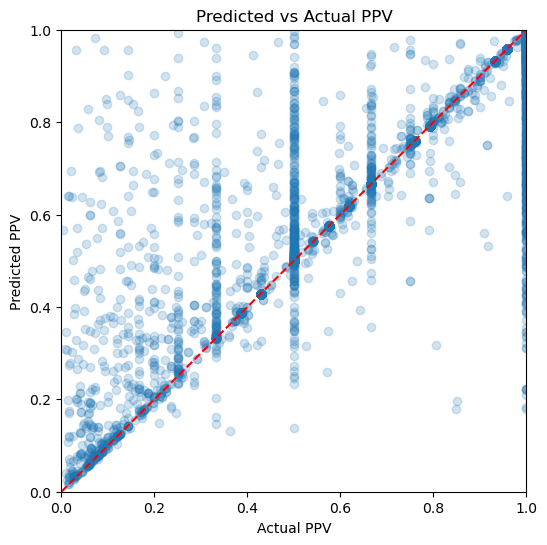

In [301]:
# let's run a random train test split first
X_baseline = final_ml.drop(columns=["resistant", "ppv", "drug"])
y_baseline = final_ml["ppv"]
print(y_baseline.isna().sum())

X_train, X_test, y_train, y_test = train_test_split(X_baseline, y_baseline, test_size=0.2, random_state=42)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.2)
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("Actual PPV")
plt.ylabel("Predicted PPV")
plt.title("Predicted vs Actual PPV")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()


In [302]:
# HOLDOUT 3 drugs
holdout_drugs = [0.0, 8.0, 2.0, 5.0]
train_df_holdout = final_ml[~final_ml["drug"].isin(holdout_drugs)].copy()
train_df_holdout = train_df_holdout.dropna(subset='ppv')
test_df_holdout  = final_ml[final_ml["drug"].isin(holdout_drugs)].copy()
test_df_holdout = test_df_holdout.dropna(subset='ppv')

X_train_holdout = train_df_holdout.drop(columns=["resistant", "ppv"])
y_train_holdout = train_df_holdout["ppv"]
X_test_holdout = test_df_holdout.drop(columns=["resistant", "ppv"])
y_test_holdout = test_df_holdout["ppv"]

print(f"Training set shape: {X_train_holdout.shape}")
print(f"Holdout set shape: {X_test_holdout.shape}")


Training set shape: (32354, 387)
Holdout set shape: (3208, 387)


In [303]:
train_keys = set(
    train_df_holdout["position"].astype(str) + "_" +
    train_df_holdout.filter(like="gene_").idxmax(axis=1)
)

test_keys = set(
    test_df_holdout["position"].astype(str) + "_" +
    test_df_holdout.filter(like="gene_").idxmax(axis=1)
)
print(len(train_keys & test_keys))

187


MAE: 0.2858470677346614
R2: 0.08643971435137587


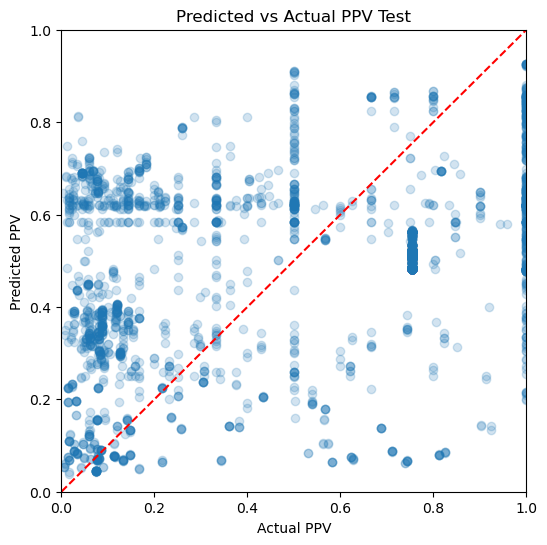

In [304]:
model_holdout = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model_holdout.fit(X_train_holdout, y_train_holdout)
y_pred_holdout = model_holdout.predict(X_test_holdout)
y_pred_holdout_train = model_holdout.predict(X_train_holdout)

print("MAE:", mean_absolute_error(y_test_holdout, y_pred_holdout))
print("R2:", r2_score(y_test_holdout, y_pred_holdout))

plt.figure(figsize=(6, 6))
plt.scatter(y_test_holdout, y_pred_holdout, alpha=0.2)
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("Actual PPV")
plt.ylabel("Predicted PPV")
plt.title("Predicted vs Actual PPV Test")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()


In [305]:
# full row overlap
train_rows = set(map(tuple, X_train_holdout.values))
test_rows = set(map(tuple, X_test_holdout.values))

print(f"Exact row overlap: {len(train_rows & test_rows)}")

train_drugs = set(train_df_holdout["drug"])
test_drugs = set(test_df_holdout["drug"])

print(f"Exact drug overlap: {len(train_drugs & test_drugs)}")

Exact row overlap: 0
Exact drug overlap: 0


In [306]:
def make_key(df):
    return (
        df["position"].astype(str) + "_" +
        df.filter(like="gene_").idxmax(axis=1)
    )

train_keys = set(make_key(train_df_holdout))
test_keys = set(make_key(test_df_holdout))

print("Mutation overlap:", len(train_keys & test_keys))

Mutation overlap: 187


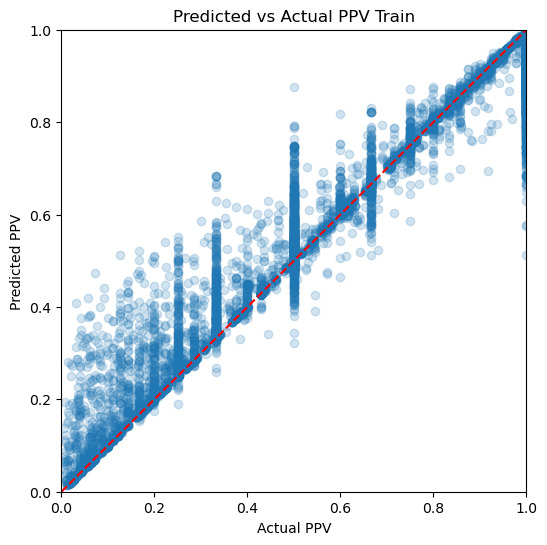

In [307]:
plt.figure(figsize=(6, 6))
plt.scatter(y_train_holdout, y_pred_holdout_train, alpha=0.2)
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("Actual PPV")
plt.ylabel("Predicted PPV")
plt.title("Predicted vs Actual PPV Train")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

In [308]:
eps = 1e-5

y_train_t = np.log((y_train + eps) / (1 - y_train + eps))
y_test_t  = np.log((y_test + eps) / (1 - y_test + eps))

In [309]:
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

# numeric features
X_train_xgb = X_train.apply(pd.to_numeric, errors="coerce")
X_test_xgb = X_test.apply(pd.to_numeric, errors="coerce")

medians = X_train_xgb.median()
X_train_xgb = X_train_xgb.fillna(medians)
X_test_xgb = X_test_xgb.fillna(medians)

# convert to numpy arrays
X_train_np = X_train_xgb.to_numpy(dtype=np.float32)
X_test_np = X_test_xgb.to_numpy(dtype=np.float32)

# make sure target is 1D numpy array
y_train_np = np.asarray(y_train_t, dtype=np.float32).ravel()

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_np, y_train_np)

y_pred_t = xgb.predict(X_test_np)
y_pred = 1 / (1 + np.exp(-y_pred_t))

In [310]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.1037057395306972
R2: 0.25899253541580036


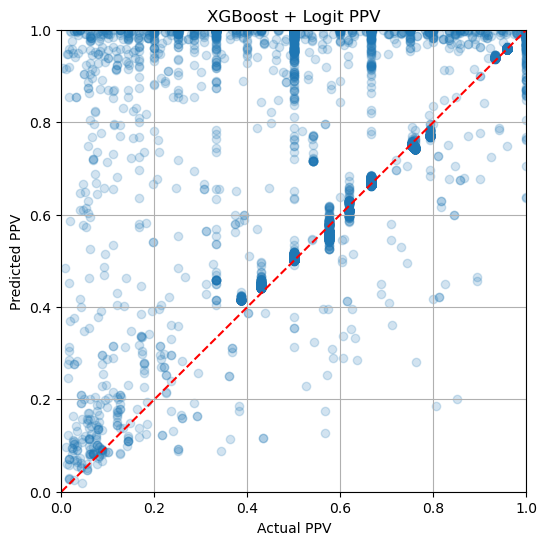

In [311]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.2)

# ideal line
plt.plot([0,1], [0,1], 'r--')

plt.xlabel("Actual PPV")
plt.ylabel("Predicted PPV")
plt.title("XGBoost + Logit PPV")

plt.xlim(0,1)
plt.ylim(0,1)

plt.grid(True)
plt.show()

### Let's change and do a mutation holdout to see if we can create a successful model that will predict PPV based on a new mutation

In [312]:
gene_key = final_ml.filter(like="gene_").idxmax(axis=1)
final_ml["mutation_key"] = gene_key + "_" + final_ml['position'].astype(str)

# features and the target
X = final_ml.drop(columns=["resistant", "ppv", "mutation_key"])
y = final_ml["ppv"]
group = final_ml["mutation_key"]

# Now we can use groupKFold to split the data
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=group)):
    print(f"Fold {fold + 1}")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train a simple model (e.g., Random Forest)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = model.predict(X_test)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

Fold 1
MAE: 0.05979085934961808
R2: 0.6970385925505869
Fold 2
MAE: 0.06596387915650526
R2: 0.6612450513508368
Fold 3
MAE: 0.06657233877428087
R2: 0.6907486710799169
Fold 4
MAE: 0.06386750909399005
R2: 0.6830691355400675
Fold 5
MAE: 0.06480599889081959
R2: 0.6653079839721185


# implement some tuning 
from sklearn.model_selection import RandomizedSearchCV

gene_key = final_ml.filter(like="gene_").idxmax(axis=1)
final_ml["mutation_key"] = gene_key + "_" + final_ml['position'].astype(str)

# features and the target
X = final_ml.drop(columns=["resistant", "ppv", "mutation_key"])
y = final_ml["ppv"]
group = final_ml["mutation_key"]

# Now we can use groupKFold to split the data
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=5)

parameter_grid = {
    'n_estimators': [100, 200, 300, 400, 500, 600],
    'max_depth': [None, 6, 8, 10, 12, 14],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 5, 10],
    'bootstrap': [True, False],
    'max_features': ['auto', 'sqrt', 'log2', 0.3, 0.5, 0.7]
}

search_grid = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=parameter_grid,
    n_iter=10,
    cv=gkf,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_absolute_error'
)

search_grid.fit(X, y, groups=group)

best_model = search_grid.best_estimator_
print("Best Hyperparameters:", best_model.get_params())


for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=group)):
    print(f"Fold {fold + 1}")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train a simple model (e.g., Random Forest)
    best_model.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = best_model.predict(X_test)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))


In [313]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
print("Feature Importances:", importances.sort_values(ascending=False).head(20))

Feature Importances: position               0.295772
fp_33                  0.105264
gene_fgd1              0.053154
fp_29                  0.041987
fp_67                  0.038467
mut_type_missense      0.030594
mut_type_SNV           0.026581
gene_fbiC              0.019265
del_len                0.014765
ref_len                0.011592
fp_140                 0.011196
alt_len                0.011164
mut_type_frameshift    0.010616
ref_G                  0.009838
fp_250                 0.009701
alt_C                  0.009422
ref_A                  0.009320
ref_C                  0.009192
alt_T                  0.009163
alt_G                  0.009077
dtype: float64


## Add more positional data by downloading gene info

In [314]:
myco = pd.read_csv("Mycobacterium_tuberculosis_H37Rv_txt_v5.txt", sep="\t")
myco.columns = myco.columns.str.strip() # strip column names of whitespace
print(myco.columns)
print(myco.head())
myco['gene_length'] = myco['Stop'] - myco['Start'] + 1
myco_subset = myco[['Refseq_ID', 'Start', 'Stop', 'Name','gene_length']].copy()
myco_subset.head()

Index(['Refseq_ID', 'Mycobrowser_Version', 'Feature', 'Start', 'Stop', 'Score',
       'Strand', 'Frame', 'Locus', 'Name', 'Function', 'Product', 'Comments',
       'UniProt_AC', 'Is_Pseudogene', 'Functional_Category',
       'Protein Data Bank', 'PFAM', 'UniProt', 'Gene Ontology',
       'Enzyme Classification', 'Drug Resistance Mutations', 'InterPro',
       'UniProtKB/TrEMBL', 'SWISS-MODEL', 'Orthologues M. leprae',
       'Orthologues M. marinum', 'Orthologues M. smegmatis',
       'Orthologues M. bovis', 'Orthologues M. lepromatosis',
       'Orthologues M. tuberculosis', 'Orthologues M. abscessus',
       'Orthologues M. haemophilum', 'Orthologues M. orygis',
       'Orthologues M. tuberculosis.1'],
      dtype='object')
     Refseq_ID Mycobrowser_Version Feature   Start    Stop Score Strand  \
0  NC_000962.3      Mycobrowser_v5   ncRNA  759479  759610     .      +   
1  NC_000962.3      Mycobrowser_v5   ncRNA  786021  786074     .      +   
2  NC_000962.3      Mycobrowser_v5   n

,Refseq_ID,Start,Stop,Name,gene_length
0,NC_000962.3,759479,759610,ncRv10666,132
1,NC_000962.3,786021,786074,ncRv10685,54
2,NC_000962.3,80240,80440,ncRv10071,201
3,NC_000962.3,80254,80344,ncRv10071c,91
4,NC_000962.3,156452,156567,ncRv10128,116


In [315]:
new_data = final_ml.copy()
needed_genes = new_data.filter(like="gene_").columns.str.replace("gene_", "", regex=False)
print(needed_genes)

matched_myco = myco_subset[myco_subset['Name'].isin(needed_genes)].copy()
print(matched_myco)

Index(['PPE35', 'Rv0010c', 'Rv0565c', 'Rv0678', 'Rv1129c', 'Rv1258c',
       'Rv1979c', 'Rv2477c', 'Rv2681', 'Rv2752c', 'Rv2983', 'Rv3083',
       'Rv3236c', 'aftB', 'ahpC', 'bacA', 'ccsA', 'clpC1', 'ddn', 'dnaA',
       'eis', 'embA', 'embB', 'embC', 'embR', 'ethA', 'ethR', 'fbiA', 'fbiB',
       'fbiC', 'fgd1', 'gid', 'glpK', 'gyrA', 'gyrB', 'hadA', 'inhA', 'katG',
       'lpqB', 'mmpL5', 'mshA', 'mtrA', 'mtrB', 'ndh', 'nusG', 'panD', 'pepQ',
       'pncA', 'rplC', 'rpoA', 'rpoB', 'rpoC', 'rpsA', 'rpsL', 'rrl', 'rrs',
       'sigE', 'tlyA', 'tsnR', 'ubiA', 'whiB6', 'whiB7'],
      dtype='object')
        Refseq_ID    Start     Stop     Name  gene_length
132   NC_000962.3  1471846  1473382      rrs         1537
165   NC_000962.3        1     1524     dnaA         1524
169   NC_000962.3     7302     9818     gyrA         2517
174   NC_000962.3    13133    13558  Rv0010c          426
310   NC_000962.3   490783   491793     fgd1         1011
...           ...      ...      ...      ...  

In [316]:
gene_cols = [c for c in new_data.columns if c.startswith("gene_") and not c.startswith("gene_length")]
new_data['gene_name'] = new_data[gene_cols].idxmax(axis=1).str.replace("gene_", "", regex=False).str.lower()
matched_myco['gene_name'] = matched_myco['Name'].str.strip().str.lower()

new_data = new_data.merge(matched_myco[['gene_name', 'gene_length', 'Start', 'Stop']], on='gene_name', how='left')
new_data = new_data.drop(columns=['gene_name'])
new_data.head()

,ppv,drug,resistant,position,del_len,ins_len,gene_PPE35,gene_Rv0010c,gene_Rv0565c,gene_Rv0678,...,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,gene_length,Start,Stop
0,0.075644,0,0,2063685.0,0.0,0.0,False,False,False,False,...,False,False,False,False,False,True,gene_bacA_2063685.0,1920,2062809,2064728
1,0.075644,0,0,2063685.0,0.0,0.0,False,False,False,False,...,False,False,False,False,True,False,gene_bacA_2063685.0,1920,2062809,2064728
2,1.000000,0,0,2063412.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,gene_bacA_2063412.0,1920,2062809,2064728
3,0.333333,0,0,2063358.0,0.0,0.0,False,False,False,False,...,False,False,False,False,False,True,gene_bacA_2063358.0,1920,2062809,2064728
4,0.035714,0,0,2063187.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,gene_bacA_2063187.0,1920,2062809,2064728


In [317]:
## add relative position of mutation in the gene
new_data['relative_position'] = (new_data['position'] - new_data['Start']) + 1
new_data['norm_position'] = new_data['relative_position'] / new_data['gene_length']
new_data = new_data.drop(columns=['Start', 'Stop'])
new_data.head()

,ppv,drug,resistant,position,del_len,ins_len,gene_PPE35,gene_Rv0010c,gene_Rv0565c,gene_Rv0678,...,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,gene_length,relative_position,norm_position
0,0.075644,0,0,2063685.0,0.0,0.0,False,False,False,False,...,False,False,False,False,False,True,gene_bacA_2063685.0,1920,877.0,0.456771
1,0.075644,0,0,2063685.0,0.0,0.0,False,False,False,False,...,False,False,False,False,True,False,gene_bacA_2063685.0,1920,877.0,0.456771
2,1.000000,0,0,2063412.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,gene_bacA_2063412.0,1920,604.0,0.314583
3,0.333333,0,0,2063358.0,0.0,0.0,False,False,False,False,...,False,False,False,False,False,True,gene_bacA_2063358.0,1920,550.0,0.286458
4,0.035714,0,0,2063187.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,gene_bacA_2063187.0,1920,379.0,0.197396


In [318]:
## change to distances
new_data['distance_to_end'] = new_data['gene_length'] - new_data['relative_position']
new_data['codon_position'] = new_data['relative_position'] % 3
new_data = new_data.drop(columns=['relative_position', 'gene_length'])
new_data.head()

,ppv,drug,resistant,position,del_len,ins_len,gene_PPE35,gene_Rv0010c,gene_Rv0565c,gene_Rv0678,...,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,norm_position,distance_to_end,codon_position
0,0.075644,0,0,2063685.0,0.0,0.0,False,False,False,False,...,False,False,False,False,False,True,gene_bacA_2063685.0,0.456771,1043.0,1.0
1,0.075644,0,0,2063685.0,0.0,0.0,False,False,False,False,...,False,False,False,False,True,False,gene_bacA_2063685.0,0.456771,1043.0,1.0
2,1.000000,0,0,2063412.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,gene_bacA_2063412.0,0.314583,1316.0,1.0
3,0.333333,0,0,2063358.0,0.0,0.0,False,False,False,False,...,False,False,False,False,False,True,gene_bacA_2063358.0,0.286458,1370.0,1.0
4,0.035714,0,0,2063187.0,0.0,0.0,False,False,False,False,...,False,True,False,False,False,False,gene_bacA_2063187.0,0.197396,1541.0,1.0


In [319]:
## drop the original position column since we have the relative position now
new_data_clean = new_data.copy()
new_data_clean = new_data_clean.drop(columns=['position'])
new_data_clean.head()

,ppv,drug,resistant,del_len,ins_len,gene_PPE35,gene_Rv0010c,gene_Rv0565c,gene_Rv0678,gene_Rv1129c,...,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,norm_position,distance_to_end,codon_position
0,0.075644,0,0,0.0,0.0,False,False,False,False,False,...,False,False,False,False,False,True,gene_bacA_2063685.0,0.456771,1043.0,1.0
1,0.075644,0,0,0.0,0.0,False,False,False,False,False,...,False,False,False,False,True,False,gene_bacA_2063685.0,0.456771,1043.0,1.0
2,1.000000,0,0,0.0,0.0,False,False,False,False,False,...,False,True,False,False,False,False,gene_bacA_2063412.0,0.314583,1316.0,1.0
3,0.333333,0,0,0.0,0.0,False,False,False,False,False,...,False,False,False,False,False,True,gene_bacA_2063358.0,0.286458,1370.0,1.0
4,0.035714,0,0,0.0,0.0,False,False,False,False,False,...,False,True,False,False,False,False,gene_bacA_2063187.0,0.197396,1541.0,1.0


In [320]:
X_old = final_ml.drop(columns=["ppv", "resistant", "mutation_key"], errors="ignore")
y = final_ml["ppv"]
groups = final_ml["mutation_key"]

X_new = new_data_clean.drop(columns=["ppv", "resistant", "mutation_key"], errors="ignore")
y_new = new_data_clean["ppv"]
groups_new = new_data_clean["mutation_key"]

gkf = GroupKFold(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_old, y, groups=groups)):
    print(f"Fold {fold + 1} - Old Data")
    X_train, X_test = X_old.iloc[train_idx], X_old.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    print("Old MAE:", mean_absolute_error(y_test, y_pred))
    print("Old R2:", r2_score(y_test, y_pred))


for fold, (train_idx, test_idx) in enumerate(gkf.split(X_new, y_new, groups=groups_new)):
    print(f"Fold {fold + 1} - New Data")
    X_train, X_test = X_new.iloc[train_idx], X_new.iloc[test_idx]
    y_train, y_test = y_new.iloc[train_idx], y_new.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("New MAE:", mean_absolute_error(y_test, y_pred))
    print("New R2:", r2_score(y_test, y_pred))



Fold 1 - Old Data
Old MAE: 0.05979085934961808
Old R2: 0.6970385925505869
Fold 2 - Old Data
Old MAE: 0.06596387915650526
Old R2: 0.6612450513508368
Fold 3 - Old Data
Old MAE: 0.06657233877428087
Old R2: 0.6907486710799169
Fold 4 - Old Data
Old MAE: 0.06386750909399005
Old R2: 0.6830691355400675
Fold 5 - Old Data
Old MAE: 0.06480599889081959
Old R2: 0.6653079839721185
Fold 1 - New Data
New MAE: 0.059559720425478524
New R2: 0.7193338519841846
Fold 2 - New Data
New MAE: 0.06623874982494281
New R2: 0.6802632079085207
Fold 3 - New Data
New MAE: 0.0666355442404644
New R2: 0.7065488714075687
Fold 4 - New Data
New MAE: 0.06316275122950486
New R2: 0.7142123250532213
Fold 5 - New Data
New MAE: 0.06530611744768183
New R2: 0.6836863351739544


In [321]:
final_ml.groupby("mutation_key")["ppv"].mean().sort_values(ascending=False).head(20)

mutation_key
gene_pncA_2289240.0    1.0
gene_rpoA_3877614.0    1.0
gene_rpoA_3877689.0    1.0
gene_rpoA_3877686.0    1.0
gene_rpoA_3877685.0    1.0
gene_rpoA_3877683.0    1.0
gene_rpoA_3877680.0    1.0
gene_rpoA_3877679.0    1.0
gene_rpoA_3877677.0    1.0
gene_rpoA_3877674.0    1.0
gene_rpoA_3877665.0    1.0
gene_rpoA_3877662.0    1.0
gene_rpoA_3877620.0    1.0
gene_rpoA_3877617.0    1.0
gene_rpoA_3877593.0    1.0
gene_rpoA_3877743.0    1.0
gene_rpoA_3877587.0    1.0
gene_rpoA_3877584.0    1.0
gene_rpoA_3877548.0    1.0
gene_rpoA_3877545.0    1.0
Name: ppv, dtype: float64

In [322]:
# let's add bins
def ppv_bin(ppv):
    if ppv >= 0.8:
        return "3"
    elif ppv >= 0.6:
        return "2"
    elif ppv >= 0.2:
        return "1"
    else:
        return "0"

new_data_clean["ppv_bin"] = new_data_clean["ppv"].apply(ppv_bin)
new_data_clean.head()

,ppv,drug,resistant,del_len,ins_len,gene_PPE35,gene_Rv0010c,gene_Rv0565c,gene_Rv0678,gene_Rv1129c,...,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,norm_position,distance_to_end,codon_position,ppv_bin
0,0.075644,0,0,0.0,0.0,False,False,False,False,False,...,False,False,False,False,True,gene_bacA_2063685.0,0.456771,1043.0,1.0,0
1,0.075644,0,0,0.0,0.0,False,False,False,False,False,...,False,False,False,True,False,gene_bacA_2063685.0,0.456771,1043.0,1.0,0
2,1.000000,0,0,0.0,0.0,False,False,False,False,False,...,True,False,False,False,False,gene_bacA_2063412.0,0.314583,1316.0,1.0,3
3,0.333333,0,0,0.0,0.0,False,False,False,False,False,...,False,False,False,False,True,gene_bacA_2063358.0,0.286458,1370.0,1.0,1
4,0.035714,0,0,0.0,0.0,False,False,False,False,False,...,True,False,False,False,False,gene_bacA_2063187.0,0.197396,1541.0,1.0,0


In [323]:
from sklearn.ensemble import RandomForestClassifier

X = new_data_clean.drop(columns=["ppv", "ppv_bin", "resistant", "mutation_key", "drug"], errors="ignore")
y = new_data_clean["ppv_bin"]
groups = new_data_clean["mutation_key"]

gkf = GroupKFold(n_splits=5)
all_results = []
metrics = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics.append({
        "fold": fold + 1,
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred)
    })

    fold_df = pd.DataFrame({
        "fold": fold + 1,
        "mutation": groups.iloc[test_idx].values,
        "actual": y_test.to_numpy(),
        "predicted": y_pred
    })

    all_results.append(fold_df)

    print(f"\nFold {fold+1}")
    print(classification_report(y_test, y_pred))
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred)}")

results_df = pd.concat(all_results, ignore_index=True)
metrics_df = pd.DataFrame(metrics)




Fold 1
              precision    recall  f1-score   support

           0       0.66      0.67      0.67       380
           1       0.89      0.85      0.87      2560
           2       0.93      0.90      0.91      1551
           3       0.83      0.89      0.86      2622

    accuracy                           0.86      7113
   macro avg       0.83      0.83      0.83      7113
weighted avg       0.87      0.86      0.87      7113

Balanced Accuracy: 0.8272944116120274

Fold 2
              precision    recall  f1-score   support

           0       0.66      0.56      0.61       417
           1       0.85      0.85      0.85      2380
           2       0.96      0.89      0.92      1546
           3       0.83      0.89      0.86      2770

    accuracy                           0.85      7113
   macro avg       0.83      0.80      0.81      7113
weighted avg       0.85      0.85      0.85      7113

Balanced Accuracy: 0.7956853201718256

Fold 3
              precision    rec

In [324]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    
    print(f"\n=== Fold {fold+1} ===")
    
    # unseen mutations in this fold
    test_mutations = groups.iloc[test_idx].unique()
    
    print(f"Number of unseen mutations: {len(test_mutations)}")
    print("Sample mutations:")
    print(test_mutations[:10])  # print first 10


=== Fold 1 ===
Number of unseen mutations: 2426
Sample mutations:
['gene_bacA_2063685.0' 'gene_bacA_2064177.0' 'gene_bacA_2063911.0'
 'gene_bacA_2062920.0' 'gene_ccsA_620311.0' 'gene_ccsA_620547.0'
 'gene_ccsA_620553.0' 'gene_ccsA_619969.0' 'gene_eis_2715345.0'
 'gene_eis_2714844.0']

=== Fold 2 ===
Number of unseen mutations: 2427
Sample mutations:
['gene_bacA_2063358.0' 'gene_bacA_2064180.0' 'gene_ccsA_620016.0'
 'gene_ccsA_620619.0' 'gene_rrs_1472895.0' 'gene_rrs_1473061.0'
 'gene_rrs_1473246.0' 'gene_rrs_1473247.0' 'gene_rrs_1473352.0'
 'gene_rrs_1472137.0']

=== Fold 3 ===
Number of unseen mutations: 2426
Sample mutations:
['gene_bacA_2062947.0' 'gene_ccsA_620280.0' 'gene_ccsA_619962.0'
 'gene_ccsA_619968.0' 'gene_eis_2715346.0' 'gene_eis_2715117.0'
 'gene_eis_2714955.0' 'gene_rrs_1473034.0' 'gene_rrs_1473051.0'
 'gene_rrs_1473062.0']

=== Fold 4 ===
Number of unseen mutations: 2427
Sample mutations:
['gene_bacA_2063187.0' 'gene_bacA_2063106.0' 'gene_bacA_2062922.0'
 'gene_ccsA_6

In [325]:
results_df.head()

,fold,mutation,actual,predicted
0,1,gene_bacA_2063685.0,0,1
1,1,gene_bacA_2063685.0,0,0
2,1,gene_bacA_2064177.0,3,0
3,1,gene_bacA_2063911.0,0,0
4,1,gene_bacA_2062920.0,0,0


In [326]:
results_df["correct"] = results_df["actual"] == results_df["predicted"]
print(results_df["correct"].mean())

0.854535740397053


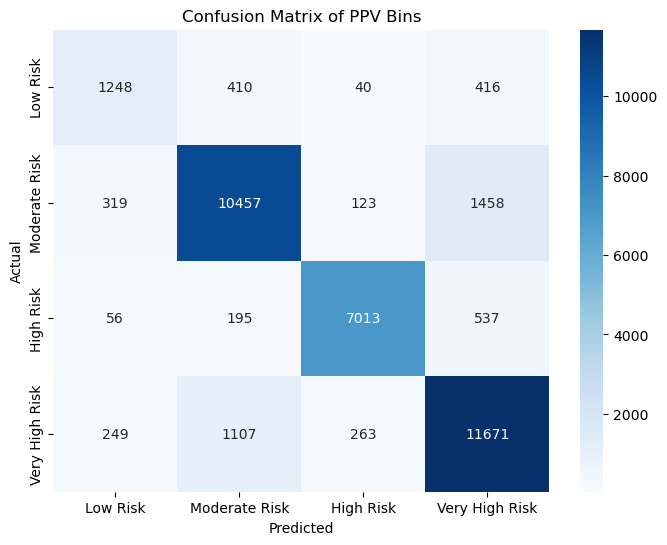

In [329]:
# let's look plot the distribution of predicted vs actual for each class as a confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(results_df["actual"], results_df["predicted"], labels=["0", "1", "2", "3"])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low Risk", "Moderate Risk", "High Risk", "Very High Risk"],
            yticklabels=["Low Risk", "Moderate Risk", "High Risk", "Very High Risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of PPV Bins")
plt.show()
